In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "regression"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR = PROJECT_ROOT / "models" / "regression"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for p in [FIG_DIR, TABLE_DIR, MODEL_DIR, OUTPUT_DIR / "predictions", OUTPUT_DIR / "tuning_results"]:
    p.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)

def add_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    if {"social_media_hours", "gaming_hours"}.issubset(out.columns):
        out["social_gaming_total_hours"] = out["social_media_hours"] + out["gaming_hours"]
    if {"notifications_per_day", "app_opens_per_day"}.issubset(out.columns):
        out["notifications_per_open"] = out["notifications_per_day"] / out["app_opens_per_day"].replace(0, 1)
    return out

df = add_features(df)

target_col = "daily_screen_time_hours"
drop_cols = {"transaction_id", "user_id", "addiction_level", "addicted_label", target_col}
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (5250, 13) Val: (1125, 13) Test: (1125, 13)


In [3]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

In [4]:
def get_reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "mse": mse,
        "rmse": mse ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    met = get_reg_metrics(y_val, y_val_pred)
    results.append({"model": name, **met})
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("rmse", ascending=True)
results_df

,model,mae,mse,rmse,r2
2,gradient_boosting,0.586715,0.476760,0.690478,0.929953
1,random_forest,0.595203,0.498437,0.706001,0.926768
0,linear_regression,0.615064,0.502337,0.708757,0.926195


C:\Users\HP\AppData\Local\Temp\ipykernel_31536\1682854946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="rmse", palette="magma")


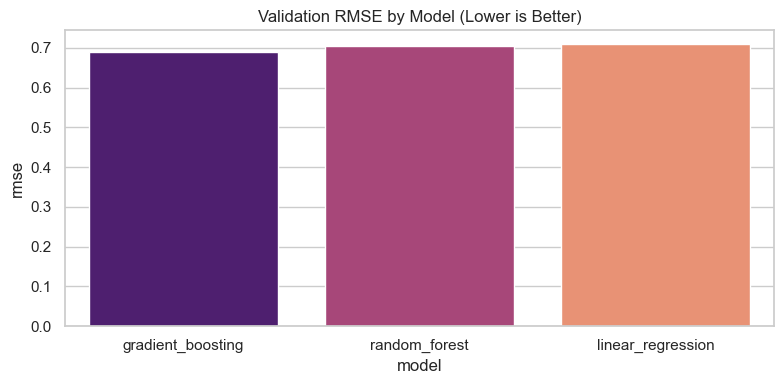

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="rmse", palette="magma")
plt.title("Validation RMSE by Model (Lower is Better)")
plt.tight_layout()
plt.savefig(FIG_DIR / "validation_rmse_model_comparison.png", dpi=300)
plt.show()

results_df.to_csv(TABLE_DIR / "regression_baseline_metrics.csv", index=False)

In [6]:
best_baseline_name = results_df.iloc[0]["model"]
print("Best baseline model:", best_baseline_name)

if best_baseline_name == "random_forest":
    estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
    }
elif best_baseline_name == "gradient_boosting":
    estimator = GradientBoostingRegressor(random_state=42)
    param_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
    }
else:
    estimator = LinearRegression()
    param_grid = {}

if param_grid:
    tuned_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    grid = GridSearchCV(
        estimator=tuned_pipeline,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    final_model = grid.best_estimator_
    cv_best_rmse = -grid.best_score_
    print("Best params:", grid.best_params_)
    print("Best CV RMSE:", round(cv_best_rmse, 4))
else:
    final_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    final_model.fit(X_train, y_train)
    cv_best_rmse = None
    print("Linear Regression selected: no grid search applied.")

Best baseline model: gradient_boosting


Best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV RMSE: 0.6645


In [7]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_model.fit(X_train_val, y_train_val)
y_test_pred = final_model.predict(X_test)

test_metrics = get_reg_metrics(y_test, y_test_pred)
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test metrics:
mae: 0.5834
mse: 0.4747
rmse: 0.6890
r2: 0.9304


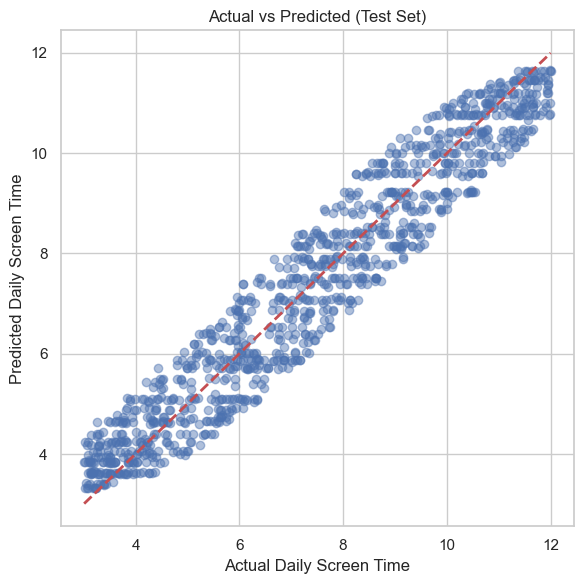

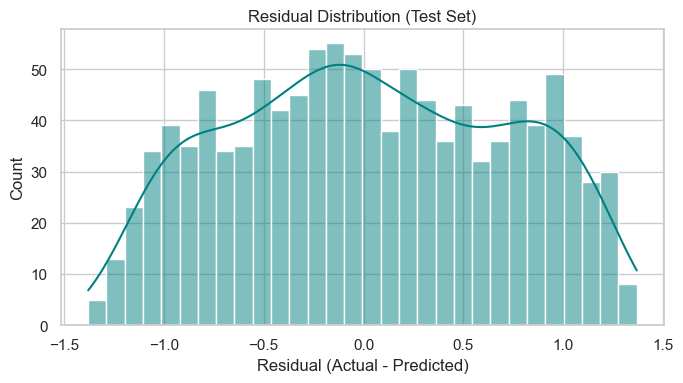

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.45)
line_min = min(y_test.min(), y_test_pred.min())
line_max = max(y_test.max(), y_test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
plt.xlabel("Actual Daily Screen Time")
plt.ylabel("Predicted Daily Screen Time")
plt.title("Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_test.png", dpi=300)
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=30, kde=True, color="teal")
plt.title("Residual Distribution (Test Set)")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution_test.png", dpi=300)
plt.show()

In [9]:
metrics_df = pd.DataFrame([
    {"metric": "test_mae", "value": test_metrics["mae"]},
    {"metric": "test_mse", "value": test_metrics["mse"]},
    {"metric": "test_rmse", "value": test_metrics["rmse"]},
    {"metric": "test_r2", "value": test_metrics["r2"]},
    {"metric": "cv_best_rmse", "value": cv_best_rmse if cv_best_rmse is not None else float("nan")},
])
metrics_df.to_csv(TABLE_DIR / "regression_metrics.csv", index=False)
metrics_df

,metric,value
0,test_mae,0.583436
1,test_mse,0.474739
2,test_rmse,0.689013
3,test_r2,0.930409
4,cv_best_rmse,0.664462


In [10]:
pred_df = pd.DataFrame({"actual": y_test.values, "predicted": y_test_pred})
pred_df.to_csv(OUTPUT_DIR / "predictions" / "regression_predictions.csv", index=False)

if "grid" in globals() and hasattr(grid, "cv_results_"):
    pd.DataFrame(grid.cv_results_).to_csv(
        OUTPUT_DIR / "tuning_results" / "regression_gridsearch_results.csv", index=False
    )

joblib.dump(final_model, MODEL_DIR / "best_regression_model.pkl")

print("Saved model and outputs:")
print("-", MODEL_DIR / "best_regression_model.pkl")
print("-", OUTPUT_DIR / "predictions" / "regression_predictions.csv")

Saved model and outputs:
- C:\Users\HP\Documents\AI\Y1S2\ML\smartphone_ml_assignment\models\regression\best_regression_model.pkl
- C:\Users\HP\Documents\AI\Y1S2\ML\smartphone_ml_assignment\outputs\predictions\regression_predictions.csv
